# Lab 2 — Enter the LLM: Same Task, Completely Different Machine

---

> **Lessons covered**: 02 Predictive vs Generative Systems · 03 Discriminative vs Generative Models  
> **Metric used**: Accuracy (same as Lab 1 — on purpose)

---

## Learning Goal

Understand that an LLM is a **text generator**, not a classifier.  
All the models in Lab 1 output a number. An LLM outputs tokens.  
Building a predictive system on top of one means wrestling with its outputs — and that struggle is the lesson.

By the end of this lab you will:

1. See what an LLM actually returns when you ask it a yes/no question
2. Experience the engineering challenge of turning free text into a usable label
3. Understand why `response_format` exists and when to use it
4. Compare LLM accuracy to XGBoost from Lab 1 — and understand *why* the result looks the way it does
5. See the same LLM behave as a **generative** system with a single prompt change

---

> **Tutor note**: The point is NOT to make the LLM win.  
> The point is to feel the difference between a discriminative model (outputs a probability directly)  
> and a generative model (outputs tokens that need to be interpreted).  
> The crashes and parsing bugs are the pedagogy — do not skip them.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

from openai import OpenAI
from dotenv import load_dotenv
import json
import time

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

load_dotenv()   # load .env so OPENAI_API_KEY is available
client = OpenAI()   # reads OPENAI_API_KEY from environment
print('Imports OK. OpenAI client ready.')

Imports OK. OpenAI client ready.


In [39]:
df = pd.read_csv(Path('../data/loan_applications.csv'))

FEATURES = [
    'credit_score', 'annual_income', 'loan_amount',
    'num_defaults', 'employment_years', 'age', 'loan_purpose'
]
TARGET = 'approved'

le = LabelEncoder()
df['loan_purpose_enc'] = le.fit_transform(df['loan_purpose'])
FEATURES_ENC = FEATURES[:-1] + ['loan_purpose_enc']

X = df[FEATURES_ENC]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Dataset: {len(df)} applicants | Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Approval rate: {y.mean():.1%}')

Dataset: 1000 applicants | Train: 800 | Test: 200
Approval rate: 65.0%


---
## Section 1 — The Naive Attempt: Just Ask It

In Lab 1 you called `model.predict(X_test)` and got back a numpy array of 0s and 1s.  
Let's try the same thing with an LLM — just ask it the question directly.

In [40]:
# Pick one applicant from the test set
sample = df[FEATURES].iloc[X_test.index[0]].to_dict()
print('Applicant we are asking about:')
for k, v in sample.items():
    print(f'  {k}: {v}')

Applicant we are asking about:
  credit_score: 726
  annual_income: 75835.35
  loan_amount: 9235.83
  num_defaults: 0
  employment_years: 2.8
  age: 26
  loan_purpose: personal


In [41]:
# The most naive possible prompt
naive_prompt = (
    f'Credit score: {sample["credit_score"]}\n'
    f'Annual income: {sample["annual_income"]}\n'
    f'Loan amount: {sample["loan_amount"]}\n'
    f'Past defaults: {sample["num_defaults"]}\n'
    f'Employment years: {sample["employment_years"]}\n'
    f'Age: {sample["age"]}\n'
    f'Loan purpose: {sample["loan_purpose"]}\n\n'
    'Should this loan be approved?'
)

response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role': 'user', 'content': naive_prompt}],
    temperature=0,
)

raw_text = response.choices[0].message.content
print('Raw LLM response:')
print('─' * 50)
print(raw_text)
print('─' * 50)
print(f'\nType: {type(raw_text)}')
print(f'Length: {len(raw_text)} characters')

Raw LLM response:
──────────────────────────────────────────────────
To determine whether the loan should be approved, we can consider several factors based on the information provided:

1. **Credit Score**: A credit score of 726 is generally considered good. Most lenders view scores above 700 as favorable, indicating that the borrower is likely to repay the loan.

2. **Annual Income**: An annual income of $75,835.35 is relatively high for a 26-year-old, suggesting that the borrower has a stable financial situation.

3. **Loan Amount**: The loan amount of $9,235.83 is a manageable sum, especially in relation to the borrower's income.

4. **Past Defaults**: Having zero past defaults is a strong positive indicator of the borrower's creditworthiness.

5. **Employment Years**: With 2.8 years of employment, the borrower has a reasonable amount of work history, which can be a positive factor in assessing stability.

6. **Age**: At 26, the borrower is relatively young, but their financial his

---
## Section 2 — Forcing a Number

OK — let's be more explicit. Tell the model to answer with **only** 0 or 1.
Surely that will work?

We'll run 20 applicants and collect the raw strings the model returns.

In [42]:
# Now try to use it the way we used Lab 1 models:
try:
    label = int(raw_text)
    print(f'Got label: {label}')
except ValueError as e:
    print(f'CRASH: {e}')
    print()
    print('This is not a number. This is a paragraph.')
    print('XGBoost gave us a numpy array. The LLM gave us an essay.')
    print('These are fundamentally different machines.')

CRASH: invalid literal for int() with base 10: "To determine whether the loan should be approved, we can consider several factors based on the information provided:\n\n1. **Credit Score**: A credit score of 726 is generally considered good. Most l

This is not a number. This is a paragraph.
XGBoost gave us a numpy array. The LLM gave us an essay.
These are fundamentally different machines.


In [43]:
def ask_for_number(applicant: dict) -> str:
    """Ask LLM to return only 0 or 1. Return the raw string — no parsing yet."""
    prompt = (
        'You are a loan officer. Based on this applicant, answer with ONLY the number 0 (deny) '
        'or 1 (approve). No explanation. No punctuation. Just the number.\n\n'
        f'Credit score: {applicant["credit_score"]}\n'
        f'Annual income: {applicant["annual_income"]:,.0f}\n'
        f'Loan amount: {applicant["loan_amount"]:,.0f}\n'
        f'Past defaults: {applicant["num_defaults"]}\n'
        f'Employment years: {applicant["employment_years"]}\n'
        f'Age: {applicant["age"]}\n'
        f'Loan purpose: {applicant["loan_purpose"]}\n\n'
        'Answer:'
    )
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0,
        max_tokens=10,
    )
    return response.choices[0].message.content  # raw string, not parsed


# Run on 20 samples and collect the raw outputs
N_PROBE = 20
test_rows = df[FEATURES].iloc[X_test.index[:N_PROBE]]

print(f'Asking the LLM about {N_PROBE} applicants...')
raw_outputs = []
for _, row in test_rows.iterrows():
    raw_outputs.append(ask_for_number(row.to_dict()))
    time.sleep(0.1)

print('\nRaw strings returned by the model:')
for i, (out, true) in enumerate(zip(raw_outputs, y_test.iloc[:N_PROBE])):
    print(f'  [{i:2d}]  repr: {repr(out):20s}   true label: {true}')

Asking the LLM about 20 applicants...

Raw strings returned by the model:
  [ 0]  repr: '1'                    true label: 1
  [ 1]  repr: '1'                    true label: 1
  [ 2]  repr: '1'                    true label: 1
  [ 3]  repr: '1'                    true label: 1
  [ 4]  repr: '1'                    true label: 0
  [ 5]  repr: '1'                    true label: 1
  [ 6]  repr: '0'                    true label: 1
  [ 7]  repr: '0'                    true label: 0
  [ 8]  repr: '0'                    true label: 0
  [ 9]  repr: '1'                    true label: 1
  [10]  repr: '1'                    true label: 1
  [11]  repr: '1'                    true label: 0
  [12]  repr: '0'                    true label: 0
  [13]  repr: '0'                    true label: 0
  [14]  repr: '1'                    true label: 1
  [15]  repr: '0'                    true label: 0
  [16]  repr: '0'                    true label: 1
  [17]  repr: '1'                    true label: 0
  [18]  

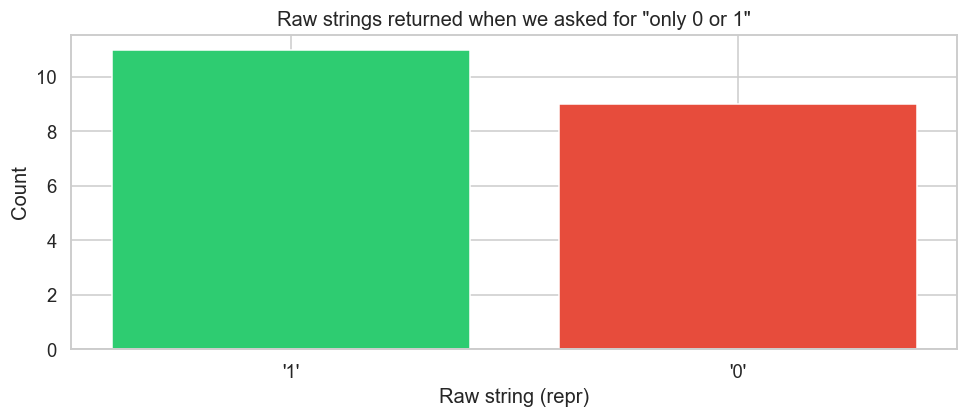


Try naively calling int() on every response:

0/20 responses crashed int()


In [44]:
# Visualise the variety of raw outputs
response_counts = Counter(raw_outputs)

fig, ax = plt.subplots(figsize=(9, 4))
labels_bar = [repr(k) for k in response_counts.keys()]
counts_bar = list(response_counts.values())
colours = ['#2ecc71' if '1' in k else '#e74c3c' if '0' in k else '#f39c12'
           for k in response_counts.keys()]
ax.bar(labels_bar, counts_bar, color=colours)
ax.set_title('Raw strings returned when we asked for "only 0 or 1"')
ax.set_xlabel('Raw string (repr)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print('\nTry naively calling int() on every response:')
crash_count = 0
for out in raw_outputs:
    try:
        int(out)
    except (ValueError, TypeError):
        crash_count += 1
        print(f'  CRASH on: {repr(out)}')
print(f'\n{crash_count}/{N_PROBE} responses crashed int()')

---
## Section 3 — Writing a Robust Parser

We need a `parse_decision()` function that handles every variant the model might return:
- `'1'`, `'0'` — ideal
- `'1 '`, `' 0'` — leading/trailing whitespace
- `'1 (approve)'` — model added context anyway
- `'One'`, `'Zero'` — sometimes uses words
- `'I would say 1.'` — full sentence
- something completely unexpected — default to 0 (safe fallback)

This parsing code is the **contract** between the generative model and the predictive system.

In [45]:
def parse_decision(raw: str) -> int:
    """
    Turn whatever the LLM returned into a binary label.
    Returns 1 (approve) or 0 (deny).
    Falls back to 0 (deny) if we cannot parse — safer than approving by accident.
    """
    cleaned = raw.strip().upper()

    # Try exact digit first
    if cleaned.startswith('1'):
        return 1
    if cleaned.startswith('0'):
        return 0

    # Word forms
    if 'ONE' in cleaned or 'APPROV' in cleaned or 'YES' in cleaned:
        return 1
    if 'ZERO' in cleaned or 'DENY' in cleaned or 'DENIED' in cleaned or 'NO' in cleaned:
        return 0

    # Unknown — safe fallback
    print(f'  [WARN] Could not parse: {repr(raw)} -> defaulting to 0')
    return 0


# Test our parser on the raw outputs we already have
parsed = [parse_decision(r) for r in raw_outputs]
print('Parser results:')
for raw, label in zip(raw_outputs, parsed):
    print(f'  {repr(raw):25s} -> {label}')

Parser results:
  '1'                       -> 1
  '1'                       -> 1
  '1'                       -> 1
  '1'                       -> 1
  '1'                       -> 1
  '1'                       -> 1
  '0'                       -> 0
  '0'                       -> 0
  '0'                       -> 0
  '1'                       -> 1
  '1'                       -> 1
  '1'                       -> 1
  '0'                       -> 0
  '0'                       -> 0
  '1'                       -> 1
  '0'                       -> 0
  '0'                       -> 0
  '1'                       -> 1
  '0'                       -> 0
  '0'                       -> 0


---
## Section 4 — The Proper Fix: Structured Output

The parsing approach works, but it is fragile.
OpenAI provides `response_format={"type": "json_object"}` — it forces the model to return valid JSON every time.

This is called **structured output**. Instead of hoping the model follows instructions, you constrain the output format at the API level.
Far more reliable. Far less parsing code.

In [46]:
def llm_loan_decision_v2(applicant: dict) -> int:
    """
    LLM as predictive system — structured output approach.
    The API guarantees valid JSON. We just parse the one field we need.
    """
    prompt = (
        'You are a loan officer. Review this applicant and return a JSON object with a single '
        'field: {"decision": 0} to deny or {"decision": 1} to approve.\n\n'
        f'Credit score: {applicant["credit_score"]}\n'
        f'Annual income: {applicant["annual_income"]:,.0f}\n'
        f'Loan amount: {applicant["loan_amount"]:,.0f}\n'
        f'Past defaults: {applicant["num_defaults"]}\n'
        f'Employment years: {applicant["employment_years"]}\n'
        f'Age: {applicant["age"]}\n'
        f'Loan purpose: {applicant["loan_purpose"]}'
    )
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0,
        max_tokens=20,
        response_format={'type': 'json_object'},
    )
    result = json.loads(response.choices[0].message.content)
    return int(result.get('decision', 0))


# Demonstrate on a single applicant — show the raw JSON before parsing
demo = df[FEATURES].iloc[X_test.index[0]].to_dict()
response_demo = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role': 'user', 'content': (
        'You are a loan officer. Review this applicant and return a JSON object with a single '
        'field: {"decision": 0} to deny or {"decision": 1} to approve.\n\n'
        f'Credit score: {demo["credit_score"]}\n'
        f'Past defaults: {demo["num_defaults"]}\n'
        f'Annual income: {demo["annual_income"]:,.0f}'
    )}],
    temperature=0,
    max_tokens=20,
    response_format={'type': 'json_object'},
)
raw_json = response_demo.choices[0].message.content
print(f'Raw JSON from model: {raw_json}')
print(f'Parsed:              {json.loads(raw_json)}')
print(f'Label:               {int(json.loads(raw_json).get("decision", 0))}')
print()
print('No custom parser. No fragile string matching. Just json.loads() on a guaranteed-valid JSON.')

Raw JSON from model: {
  "decision": 1
}
Parsed:              {'decision': 1}
Label:               1

No custom parser. No fragile string matching. Just json.loads() on a guaranteed-valid JSON.


---
## Section 5 — Accuracy Check: LLM vs XGBoost

Now let's actually measure how well it does — using the same metric from Lab 1: **accuracy**.

We'll run both models on the same 50 test applicants and compare head-to-head.

In [47]:
# Train XGBoost (same setup as Lab 1) — our baseline
xgb = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_acc   = accuracy_score(y_test, xgb_preds)
print(f'XGBoost accuracy (full test set, {len(X_test)} samples): {xgb_acc:.3f}')

XGBoost accuracy (full test set, 200 samples): 0.895


In [48]:
# Run LLM v2 (structured output) on 50 test samples
N_EVAL = 50
test_subset = df[FEATURES].iloc[X_test.index[:N_EVAL]]
y_test_subset = y_test.iloc[:N_EVAL]

print(f'Running LLM on {N_EVAL} test applicants (structured output)...')
llm_preds = []
for _, row in test_subset.iterrows():
    llm_preds.append(llm_loan_decision_v2(row.to_dict()))
    time.sleep(0.1)

llm_acc = accuracy_score(y_test_subset, llm_preds)
xgb_acc_subset = accuracy_score(y_test_subset, xgb.predict(X_test.iloc[:N_EVAL]))

print(f'\nOn the same {N_EVAL} applicants:')
print(f'  XGBoost accuracy: {xgb_acc_subset:.3f}')
print(f'  LLM accuracy:     {llm_acc:.3f}')


Running LLM on 50 test applicants (structured output)...

On the same 50 applicants:
  XGBoost accuracy: 0.920
  LLM accuracy:     0.660


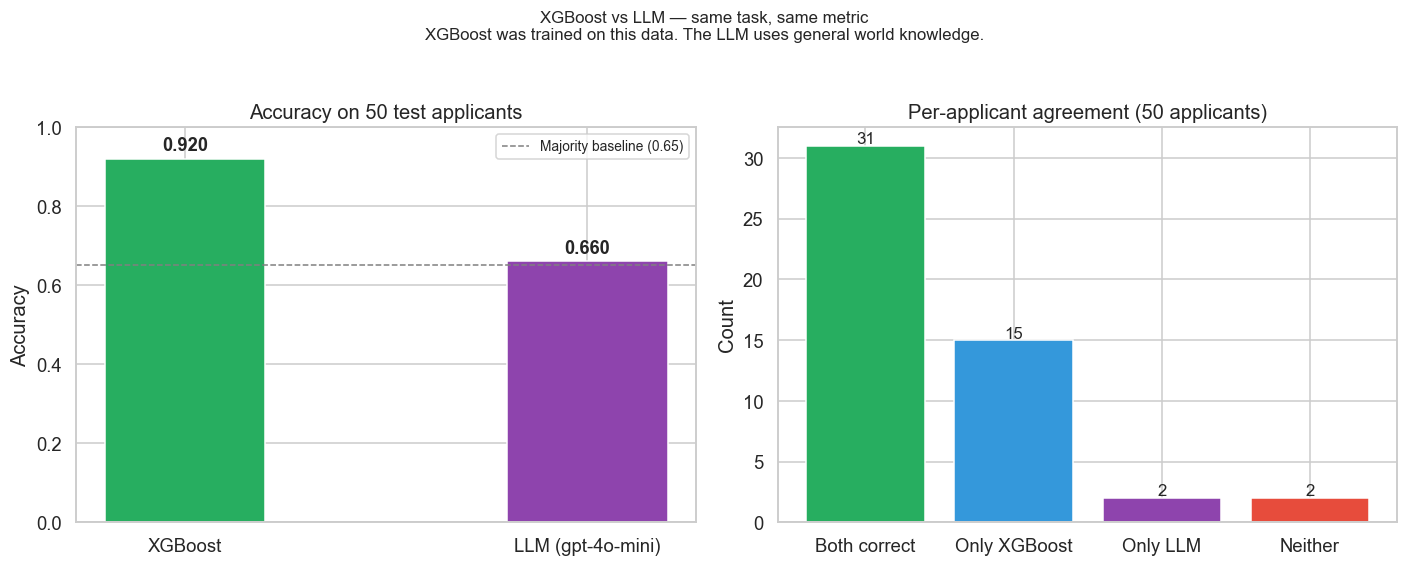


Key observation:
XGBoost learned the exact patterns in this dataset from labelled training data.
The LLM uses general world knowledge about lending — no training on this data at all.
On structured tabular data: discriminative models win. That is correct, not a failure.


In [49]:
# Visualise: head-to-head accuracy bar + per-applicant agreement breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
models_names = ['XGBoost', 'LLM (gpt-4o-mini)']
accs = [xgb_acc_subset, llm_acc]
colours = ['#27ae60', '#8e44ad']
bars = ax1.bar(models_names, accs, color=colours, width=0.4)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width() / 2, acc + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Accuracy')
ax1.set_title(f'Accuracy on {N_EVAL} test applicants')
ax1.axhline(y_test.mean(), color='gray', linestyle='--',
            linewidth=1, label=f'Majority baseline ({y_test.mean():.2f})')
ax1.legend(fontsize=9)

# Per-applicant agreement breakdown
xgb_preds_sub = xgb.predict(X_test.iloc[:N_EVAL])
both_correct  = sum((x == t) and (l == t) for x, l, t in zip(xgb_preds_sub, llm_preds, y_test_subset))
only_xgb      = sum((x == t) and (l != t) for x, l, t in zip(xgb_preds_sub, llm_preds, y_test_subset))
only_llm      = sum((x != t) and (l == t) for x, l, t in zip(xgb_preds_sub, llm_preds, y_test_subset))
neither       = sum((x != t) and (l != t) for x, l, t in zip(xgb_preds_sub, llm_preds, y_test_subset))

outcome_names  = ['Both correct', 'Only XGBoost', 'Only LLM', 'Neither']
outcome_counts = [both_correct, only_xgb, only_llm, neither]
outcome_colours = ['#27ae60', '#3498db', '#8e44ad', '#e74c3c']
bars2 = ax2.bar(outcome_names, outcome_counts, color=outcome_colours)
for bar, cnt in zip(bars2, outcome_counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, cnt + 0.2, str(cnt),
             ha='center', fontsize=11)
ax2.set_title(f'Per-applicant agreement ({N_EVAL} applicants)')
ax2.set_ylabel('Count')

plt.suptitle(
    'XGBoost vs LLM — same task, same metric\n'
    'XGBoost was trained on this data. The LLM uses general world knowledge.',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.show()

print('\nKey observation:')
print('XGBoost learned the exact patterns in this dataset from labelled training data.')
print('The LLM uses general world knowledge about lending — no training on this data at all.')
print('On structured tabular data: discriminative models win. That is correct, not a failure.')

---
## Section 6 — The Generative Flip

We have been using the LLM as a **predictive system** — we constrained its output to a label.
But the model itself is generative. It can do something XGBoost fundamentally cannot:

**Write an explanation.**

No prompt engineering trick will make XGBoost explain its decision in plain English.
For the LLM, it is a single prompt change.

This is the real difference between discriminative and generative models.

In [50]:
def llm_with_explanation(applicant: dict) -> dict:
    """
    LLM as GENERATIVE system.
    Same model. Different prompt. Now it explains its decision.
    """
    prompt = (
        'You are a loan officer at a consumer bank. Review this application and provide:\n'
        '1. Your decision: APPROVE or DENY\n'
        '2. A clear, professional explanation (2-3 sentences) the applicant will actually receive\n\n'
        f'Credit score: {applicant["credit_score"]}\n'
        f'Annual income: {applicant["annual_income"]:,.0f}\n'
        f'Loan amount: {applicant["loan_amount"]:,.0f}\n'
        f'Past defaults: {applicant["num_defaults"]}\n'
        f'Employment years: {applicant["employment_years"]}\n'
        f'Age: {applicant["age"]}\n'
        f'Loan purpose: {applicant["loan_purpose"]}\n\n'
        'Return JSON: {"decision": "APPROVE or DENY", "explanation": "..."}'
    )
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.3,
        max_tokens=200,
        response_format={'type': 'json_object'},
    )
    return json.loads(response.choices[0].message.content)


# Pick 3 illustrative cases (fallbacks if no row matches strict criteria)
test_rows = df[FEATURES].iloc[X_test.index].copy()
test_rows['actual'] = y_test.values

strong_approve = test_rows[test_rows['credit_score'] > 750].iloc[0] if (test_rows['credit_score'] > 750).any() else test_rows.nlargest(1, 'credit_score').iloc[0]
clear_deny_candidates = test_rows[(test_rows['credit_score'] < 550) | (test_rows['num_defaults'] > 1)]
clear_deny = clear_deny_candidates.iloc[0] if len(clear_deny_candidates) else test_rows.nsmallest(1, 'credit_score').iloc[0]
borderline_candidates = test_rows[test_rows['credit_score'].between(580, 640)]
borderline = borderline_candidates.iloc[0] if len(borderline_candidates) else test_rows.iloc[len(test_rows) // 2]

print('Generating LLM explanations...\n')
for label, row in [('Strong approval', strong_approve), ('Clear denial', clear_deny), ('Borderline', borderline)]:
    result = llm_with_explanation(row.to_dict())
    actual = 'Approved' if row['actual'] == 1 else 'Denied'
    print(f'-- {label} -- (ground truth: {actual})')
    print(f'  LLM decision:    {result.get("decision", "?")}')
    print(f'  LLM explanation: {result.get("explanation", "?")}')
    print()

Generating LLM explanations...

-- Strong approval -- (ground truth: Approved)
  LLM decision:    DENY
  LLM explanation: While your credit score is excellent and you have no past defaults, your lack of employment history raises concerns about your ability to repay the loan. Additionally, your annual income may not be sufficient to support the requested loan amount.

-- Clear denial -- (ground truth: Denied)
  LLM decision:    DENY
  LLM explanation: While your credit score is excellent, the two past defaults raise concerns about your repayment history. Additionally, the loan amount requested is significant relative to your annual income, which may impact your ability to manage the loan alongside your existing financial obligations.

-- Borderline -- (ground truth: Approved)
  LLM decision:    APPROVE
  LLM explanation: Your application has been approved based on your stable employment history, consistent income, and absence of past defaults. While your credit score is on the lower sid

---
## Key Takeaways — Lab 2

### What happened in this lab

| Step | What we learned |
|---|---|
| Naive prompt | LLM returns free text — `int()` crashes immediately |
| Force a number | Model mostly complies, but still varies: `'1'`, `'1 (approve)'`, `' 1'` |
| Robust parser | Engineering work needed to make a generative output usable as a label |
| Structured output | `response_format` is the clean, reliable fix |
| Accuracy comparison | XGBoost wins on tabular data — it was *trained* on this exact task |
| Generative flip | One prompt change unlocks explanations — something XGBoost cannot do |

### The Core Distinction

| | Discriminative model (XGBoost) | Generative model (LLM) |
|---|---|---|
| **Learns** | `P(label \| features)` directly | `P(next token \| context)` |
| **Output** | Number / probability | Tokens (text) |
| **As predictive system** | Native — no wrapper needed | Needs prompt + parsing |
| **As generative system** | Not possible | One prompt change |
| **Structured tabular data** | Strong | Weak |
| **Can write a letter** | No | Yes |

### What's Next — Lab 3

We have been saving results in `print()` statements.
We now have two different model types (Lab 1 + Lab 2) with no way to track them over time.
**Lab 3 will introduce MLflow** — so nothing gets lost and every run is reproducible.